In [161]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

In [162]:
class ThreeStageCIC:
    def __init__(self, R1=16, R2=4, R3=2, cic_order=4, M=1, fs=12800000, fin=10000, hb_taps=None, is_taps=31, passband_frac=0.4):
        """
        Initializes the 3-Stage CIC Decimator.
        
        Parameters:
        R1 : int - Decimation ratio for Stage 1 (CIC)
        R2 : int - Decimation ratio for Stage 2 (Cascaded Half-Band equivalent)
        R3 : int - Decimation ratio for Stage 3 (Inverse Sinc)
        cic_order : int - Order (number of stages) of the CIC filter
        hb_taps : int - Number of taps for the Stage 2 filter
        is_taps : int - Number of taps for the Stage 3 (Inverse Sinc) filter
        passband_frac : float - Passband edge fraction (0 to 1) for Inverse Sinc compensation
        """
        self.R1 = R1
        self.R2 = R2
        self.R3 = R3
        self.cic_order = cic_order
        self.M = M
        self.hb_taps = [tap | 1 for tap in hb_taps]
        self.is_taps = is_taps | 1  # Ensure odd number of taps
        self.passband_frac = passband_frac
        self.fs = fs
        self.f_out = fs/(R1*R2*R3)
        self.f_nqst = self.f_out/2
        self.fin = fin

        
        self._design_filters()

    def _design_filters(self):
        f_main = np.linspace(1e-5, self.fs / 2, 200000)
        # f_main = np.linspace(1e-5, self.fs, 200000)
        # ---------------------------------------------------------
        # Stage 1: CIC Filter Equivalent Impulse Response
        # ---------------------------------------------------------
        # A single CIC stage impulse response is a boxcar of length R1.
        # For K stages, we convolve the boxcar with itself K-1 times.

        boxcar = np.ones(self.R1*self.M)
        self.cic_ir = boxcar
        for _ in range(self.cic_order - 1):
            self.cic_ir = np.convolve(self.cic_ir, boxcar)


        dc_gain = (self.R1*self.M)**self.cic_order
        omega_in = 2 * np.pi * f_main / self.fs
        num_in = 1 - np.exp(-1j * omega_in * self.R1 * self.M)
        den_in = 1 - np.exp(-1j * omega_in)
        H_cic_in = np.where(np.abs(den_in) < 1e-12, dc_gain, num_in / den_in) ** self.cic_order
        H_cic_in_norm = H_cic_in / dc_gain
        self.stage1_tf = H_cic_in_norm

        self.cic_ir = self.cic_ir/ dc_gain
            
        # ---------------------------------------------------------
        # Stage 2: Half-Band Filters (Equivalent Composite FIR)
        # ---------------------------------------------------------
        # Designed as a lowpass filter to prevent aliasing before decimation by R2.
        # Cutoff frequency is set to Nyquist / R2.
        # self.hb_ir = signal.firwin(self.hb_taps, 1.0 / self.R2)
        def design_halfband_fir(num_taps=31):
            """Designs a Type-1 Linear Phase Half-Band FIR filter."""
            if num_taps % 2 == 0:
                num_taps += 1
            taps = signal.firwin(num_taps, 0.25, window=('kaiser', 5.0), fs=1.0)
            center = num_taps // 2
            for i in range(num_taps):
                if (i - center) % 2 == 0 and i != center:
                    taps[i] = 0.0
            taps[center] = 0.5
            # odd_taps_sum = np.sum(taps) - taps[center]
            # for i in range(num_taps):
            #     if (i - center) % 2 != 0: # Targets only the non-zero odd taps
            #         taps[i] = taps[i] * (0.5 / odd_taps_sum)

            left_side = taps[:center]
            left_sum = np.sum(left_side)
            # while (left_sum != 0.25):
            if left_sum != 0:
                left_side = left_side * (0.25 / left_sum)
            left_sum = np.sum(left_side)
            
            # 4. Mirror left side to right side to preserve perfect symmetry
            taps[:center] = left_side
            taps[center+1:] = left_side[::-1]
            taps[center] = 1.0 - np.add(np.sum(taps[:center]), np.sum(taps[center+1:]))

            # 5. Absorb tiny residual floating-point summation errors symmetrically
            # residue = 1.0 - np.sum(taps)
            # if residue != 0:
            #     # Find the first non-zero tap index to safely absorb the error
            #     first_nonzero = np.nonzero(taps)[0][0]
            #     # Distribute residue evenly to the symmetric pair
            #     taps[first_nonzero] += residue / 2
            #     taps[num_taps - 1 - first_nonzero] += residue / 2

            print(f'sum of right cofficient {np.sum(taps[center+1:])}')
            print(f'sum of left cofficient {np.sum(taps[:center])}')
            print(f'sum of center cofficient {np.sum(taps[center])}')
            print(f'sum of center cofficient {np.sum(taps)}')
            return taps

        numb_stages = int(np.log2(self.R2))
        # hb_taps = design_halfband_fir(self.hb_taps)
        # n_hb = np.arange(len(hb_taps))
        f_in = self.fs/self.R1
        H_hb_cascade_in = np.ones(len(f_main), dtype=complex)
        total_hb_ir = np.array([1.0])
        if(numb_stages != len(self.hb_taps)):
            raise ValueError(f"total taps and decimation ratio are not same {len(self.hb_taps)} and {numb_stages}")
        for i in range(numb_stages):
            hb_taps = design_halfband_fir(self.hb_taps[i])
            n_hb = np.arange(len(hb_taps))
            fs_current = f_in / (2 ** i)
            omega_stage = 2 * np.pi * f_main / fs_current
            H_stage = np.dot(np.exp(-1j * np.outer(omega_stage, n_hb)), hb_taps)
            H_hb_cascade_in *= H_stage
            print(hb_taps*2**16)
            total_hb_ir = np.convolve(total_hb_ir, hb_taps)

        self.stage2_tf = H_hb_cascade_in

        # total_hb_ir = hb_taps.copy()
        for i in range(1, numb_stages):
            # Each successive stage is upsampled by 2^i relative to the f_in rate
            upsample_factor = 2 ** i
            # Create the upsampled version of the base taps (inserting zeros)
            hb_up = np.zeros(len(hb_taps) * upsample_factor)
            hb_up[::upsample_factor] = hb_taps
            # Convolve with the running total impulse response
            total_hb_ir = np.convolve(total_hb_ir, hb_up)

        self.hb_ir = total_hb_ir

        # ---------------------------------------------------------
        # Stage 3: Inverse Sinc Filter
        # ---------------------------------------------------------
        # Designed to compensate for the CIC passband droop.
        # def cic_droop(f_norm_in):
        #     f = np.maximum(f_norm_in, 1e-10) # Avoid division by zero
        #     return np.abs(np.sin(np.pi * f * self.R1) / (self.R1 * np.sin(np.pi * f))) ** self.cic_order

        f_in = f_in/self.R2
        nyq_in3 = f_in / 2.0
        f_stop = f_in / 4.0
        bands = [0,self.fin, f_stop, nyq_in3]

        f_fit = np.linspace(0, self.fin, 20)
        omega_fit = 2 * np.pi * f_fit / self.fs
        num_fit = np.sin(omega_fit * self.R1*self.M * 1 / 2.0)
        den_fit = np.sin(omega_fit / 2.0)
        H_fit = np.ones_like(f_fit)
        mask = omega_fit > 0
        H_fit[mask] = np.abs(num_fit[mask] / den_fit[mask]) ** self.cic_order / ((self.R1*self.M)**self.cic_order)
        desired_pass = 1.0 / H_fit
        desired = [desired_pass[0], desired_pass[-1], 0.0, 0.0]

        taps = signal.firls(self.is_taps, bands, desired, fs=f_in)
        taps = taps / np.sum(taps)  # Normalize DC gain
        n_taps = np.arange(len(taps))
        omega_stage3_grid = 2 * np.pi * f_main / f_in
        H_stage3_in = np.dot(np.exp(-1j * np.outer(omega_stage3_grid, n_taps)), taps)
        self.stage3_tf = H_stage3_in

        self.is_ir = taps
        
        self.f_main = f_main

        # Frequencies defined relative to Stage 3 Nyquist rate
        # We compensate up to passband_frac, then drop to 0
        # freqs = np.array([0.0, self.passband_frac, 0.6, 1.0])
        
        # Calculate actual baseband frequencies corresponding to these points
        # f_0 = 1e-10
        # f_pass = self.passband_frac * 0.5 / (self.R1 * self.R2)
        
        # mag_0 = 1.0 / cic_droop(f_0)
        # mag_pass = 1.0 / cic_droop(f_pass)
        
        # desired_mags = np.array([mag_0, mag_pass, 0.0, 0.0])
        
        # self.is_ir = signal.firwin2(self.is_taps, freqs, desired_mags)

    def plot_total_tf(self):
        """
        Calculates the total transfer function referenced to the high-speed input 
        sample rate and plots its magnitude response in log scale.
        """

        total_tf = self.stage1_tf*self.stage2_tf*self.stage3_tf
        mag_db = 20 * np.log10(np.abs(total_tf) + 1e-10)
        mag_db_1 = 20 * np.log10(np.abs(self.stage1_tf) + 1e-10)
        mag_db_2 = 20 * np.log10(np.abs(self.stage2_tf*self.stage1_tf) + 1e-10)

        phase_rad = np.unwrap(np.angle(total_tf))
        phase_deg = np.rad2deg(phase_rad)
        
        f_main_khz = self.f_main
        fs_khz = self.fs

        # Define stage configurations: (mag_data, decimation_factor, f_slope_start, start_db, title)
        stages = [
            (
                mag_db_1,
                self.R1,
                (1.4303 * fs_khz) / self.R1,
                -13.36 * self.cic_order,
                "Stage 1 Response",
            ),
            (
                mag_db_2,
                self.R1 * self.R2,
                (0.9 * fs_khz) / (self.R1 * self.R2 * 2),
                0.0,
                "Stage 2 Response",
            ),
            (
                mag_db,
                self.R1 * self.R2 * self.R3,
                fs_khz / (self.R1 * self.R2 * self.R3 * 2),
                0.0,
                "Stage 3 Full System Response",
            ),
        ]

        # 2. Setup 5 stacked subplots with shared X axes for aligned zooming
        fig, axes = plt.subplots(5, 1, figsize=(14, 20), sharex=False)
        plt.subplots_adjust(hspace=0.35)

        # 3. Plot Stages 1 to 3 Magnitude
        for idx, (mag, R_total, f_start, start_db, title) in enumerate(stages):
            ax = axes[idx]
            f_nyq_khz = fs_khz / (2 * R_total)

            # Plot transfer function magnitude
            ax.plot(f_main_khz,mag,color="#1f77b4",linewidth=1.5,label="Magnitude (dB)",)

            # Plot asymptotic rolloff line
            f_slope = np.array([f_start, fs_khz])
            mag_slope = start_db - (20 * self.cic_order) * np.log10(f_slope / f_slope[0] )
            ax.plot(f_slope, mag_slope, color="#d62728", linestyle="--", linewidth=2, label=f"Asymptotic Rolloff (-{20 * self.cic_order} dB/dec)",)

            # Nyquist frequency marker
            ax.axvline(f_nyq_khz, color="#9467bd", linestyle=":", linewidth=2, label=f"Nyquist Freq ({f_nyq_khz:.2f} kHz)",)

            ax.set_xscale("log")
            ax.set_ylabel("Magnitude (dB)")
            ax.set_title(title, fontweight="bold")
            ax.grid(True, which="both", linestyle="--", alpha=0.5)
            ax.legend(loc="lower left", framealpha=0.9)

        # 4. Plot Stage 3 Unwrapped Phase
        ax_phase = axes[3]
        ax_phase.plot(f_main_khz,phase_deg,color="#2ca02c",linewidth=1.5,label="Phase (Degrees)",)
        f_nyq_s3 = fs_khz / (2 * self.R1 * self.R2 * self.R3)
        ax_phase.axvline(f_nyq_s3,color="#9467bd",linestyle=":",linewidth=2,label=f"Nyquist Freq ({f_nyq_s3:.2f} kHz)",)

        ax_phase.set_xscale("log")
        ax_phase.set_xlabel("Frequency (kHz)")
        ax_phase.set_ylabel("Phase (deg)")
        ax_phase.set_ylim(-5000, 1000)
        ax_phase.set_title("Stage 3 Phase Response", fontweight="bold")
        ax_phase.grid(True, which="both", linestyle="--", alpha=0.5)
        ax_phase.legend(loc="lower left", framealpha=0.9)

        # 5. Plot Passband Ripple Zoom (Plot 5 - Hz Scale)
        ax_zoom = axes[4]
        f_nyq_hz = self.fs / (2 * self.R1 * self.R2 * self.R3)

        ax_zoom.plot(self.f_main,mag_db,color="#1f77b4",linewidth=1.5,label="Passband Detail",)
        ax_zoom.axvline(f_nyq_hz,color="#9467bd",linestyle=":",linewidth=2,label=f"Nyquist Freq ({f_nyq_hz:.2f} Hz)",)

        ax_zoom.set_xscale("log")
        ax_zoom.set_ylim(-1, 1)
        ax_zoom.set_xlabel("Frequency (Hz)")
        ax_zoom.set_ylabel("Magnitude (dB)")
        ax_zoom.set_title("Stage 3 Passband Zoom", fontweight="bold")
        ax_zoom.grid(True, which="both", linestyle="--", alpha=0.5)
        ax_zoom.legend(loc="lower left", framealpha=0.9)

        plt.tight_layout()
        plt.show()

    def calculate_clean_peak_to_peak(self, signal_data, sample_indices, transient_cutoff=15000):
        """
        Calculates the true peak-to-peak value by ignoring the initial transient.
        
        Parameters:
        - signal_data: array-like, the amplitude values of your stage output
        - sample_indices: array-like, the index array (x-axis in your plot)
        - transient_cutoff: int, index value below which data is discarded (default 15,000)
        """
        # Convert inputs to numpy arrays
        signal_data = np.asarray(signal_data)
        sample_indices = np.asarray(sample_indices)
        
        # Mask out everything during the initial settling period (X < transient_cutoff)
        steady_state_mask = sample_indices > transient_cutoff
        clean_signal = signal_data[steady_state_mask]
        
        # Calculate true peak-to-peak amplitude
        p2p_value = np.max(clean_signal) - np.min(clean_signal)
        return round(p2p_value,6), round(np.max(clean_signal),6), round(np.min(clean_signal),6)
    
    def process_and_plot(self, bitstream):
        """
        Takes a 1-bit input stream, processes it through the 3 decimation stages,
        and plots the input along with the output of each stage.
        """
        # Stage 1 processing (Filter then decimate)
        out1 = signal.lfilter(self.cic_ir, [1.0], bitstream)[::self.R1]
        
        # Stage 2 processing (Filter then decimate)
        out2 = signal.lfilter(self.hb_ir, [1.0], out1)[::self.R2]
        
        # Stage 3 processing (Filter then decimate)
        out3 = signal.lfilter(self.is_ir, [1.0], out2)[::self.R3]
        
        # Create time vectors for plotting
        t_in = np.arange(len(bitstream))
        t_out1 = np.arange(len(out1)) * self.R1
        t_out2 = np.arange(len(out2)) * (self.R1 * self.R2)
        t_out3 = np.arange(len(out3)) * (self.R1 * self.R2 * self.R3)

        print(f'stage 1 p-p value: {self.calculate_clean_peak_to_peak(out1, t_out1, 40000)}')
        print(f'stage 2 p-p value: {self.calculate_clean_peak_to_peak(out2, t_out2, 40000)}')
        print(f'stage 3 p-p value: {self.calculate_clean_peak_to_peak(out3, t_out3, 40000)}')
        # Plotting
        fig, axs = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
        
        # Plot 1: Input bitstream (plot first 500 points for visibility if large)
        limit = min(2000, len(bitstream))
        axs[0].step(t_in[:limit], bitstream[:limit], where='post', color='k', linewidth=1)
        axs[0].set_title('Input 1-Bit Stream (Delta-Sigma)')
        axs[0].set_ylabel('Amplitude')
        axs[0].grid(True)
        
        # Plot 2: Stage 1 Output
        axs[1].plot(t_out1, out1, color='r', marker='.')
        axs[1].set_title(f'Stage 1 Output (CIC, Decimated by {self.R1})')
        axs[1].set_ylabel('Amplitude')
        axs[1].set_ylim(0.498, 0.502)
        axs[1].grid(True)
        
        # Plot 3: Stage 2 Output
        axs[2].plot(t_out2, out2, color='g', marker='o')
        axs[2].set_title(f'Stage 2 Output (Half-Band, Decimated by {self.R2})')
        axs[2].set_ylabel('Amplitude')
        axs[2].set_ylim(0.498, 0.502)
        axs[2].grid(True)
        
        # Plot 4: Stage 3 Output
        axs[3].plot(t_out3, out3, color='b', marker='s')
        axs[3].set_title(f'Stage 3 Output (Inverse Sinc, Decimated by {self.R3})')
        axs[3].set_ylabel('Amplitude')
        axs[3].set_xlabel('Sample Index (Referenced to High-Speed Input Rate)')
        axs[3].set_ylim(0.498, 0.502)
        axs[3].grid(True)
        
        plt.tight_layout()
        plt.show()

In [163]:
fs_high = 12800000
f_signal = 1000
duration = 0.005

# hb_taps = log2(R2) if r2 4  len 2 re = 8 len = 3
decimator = ThreeStageCIC(R1=64, R2=4, R3=2, cic_order=4, fs =fs_high, hb_taps=[15, 11], is_taps=19, fin=12500)

sum of right cofficient 0.24999999999999997
sum of left cofficient 0.24999999999999997
sum of center cofficient 0.5
sum of center cofficient 1.0000000000000002
[ -109.19422313     0.          1127.22875348     0.
 -4523.29287171     0.         19889.25834136 32768.
 19889.25834136     0.         -4523.29287171     0.
  1127.22875348     0.          -109.19422313]
sum of right cofficient 0.25000000000000006
sum of left cofficient 0.25
sum of center cofficient 0.5
sum of center cofficient 1.0
[  153.66126561     0.         -2894.44605157     0.
 19124.78478597 32768.         19124.78478597     0.
 -2894.44605157     0.           153.66126561]


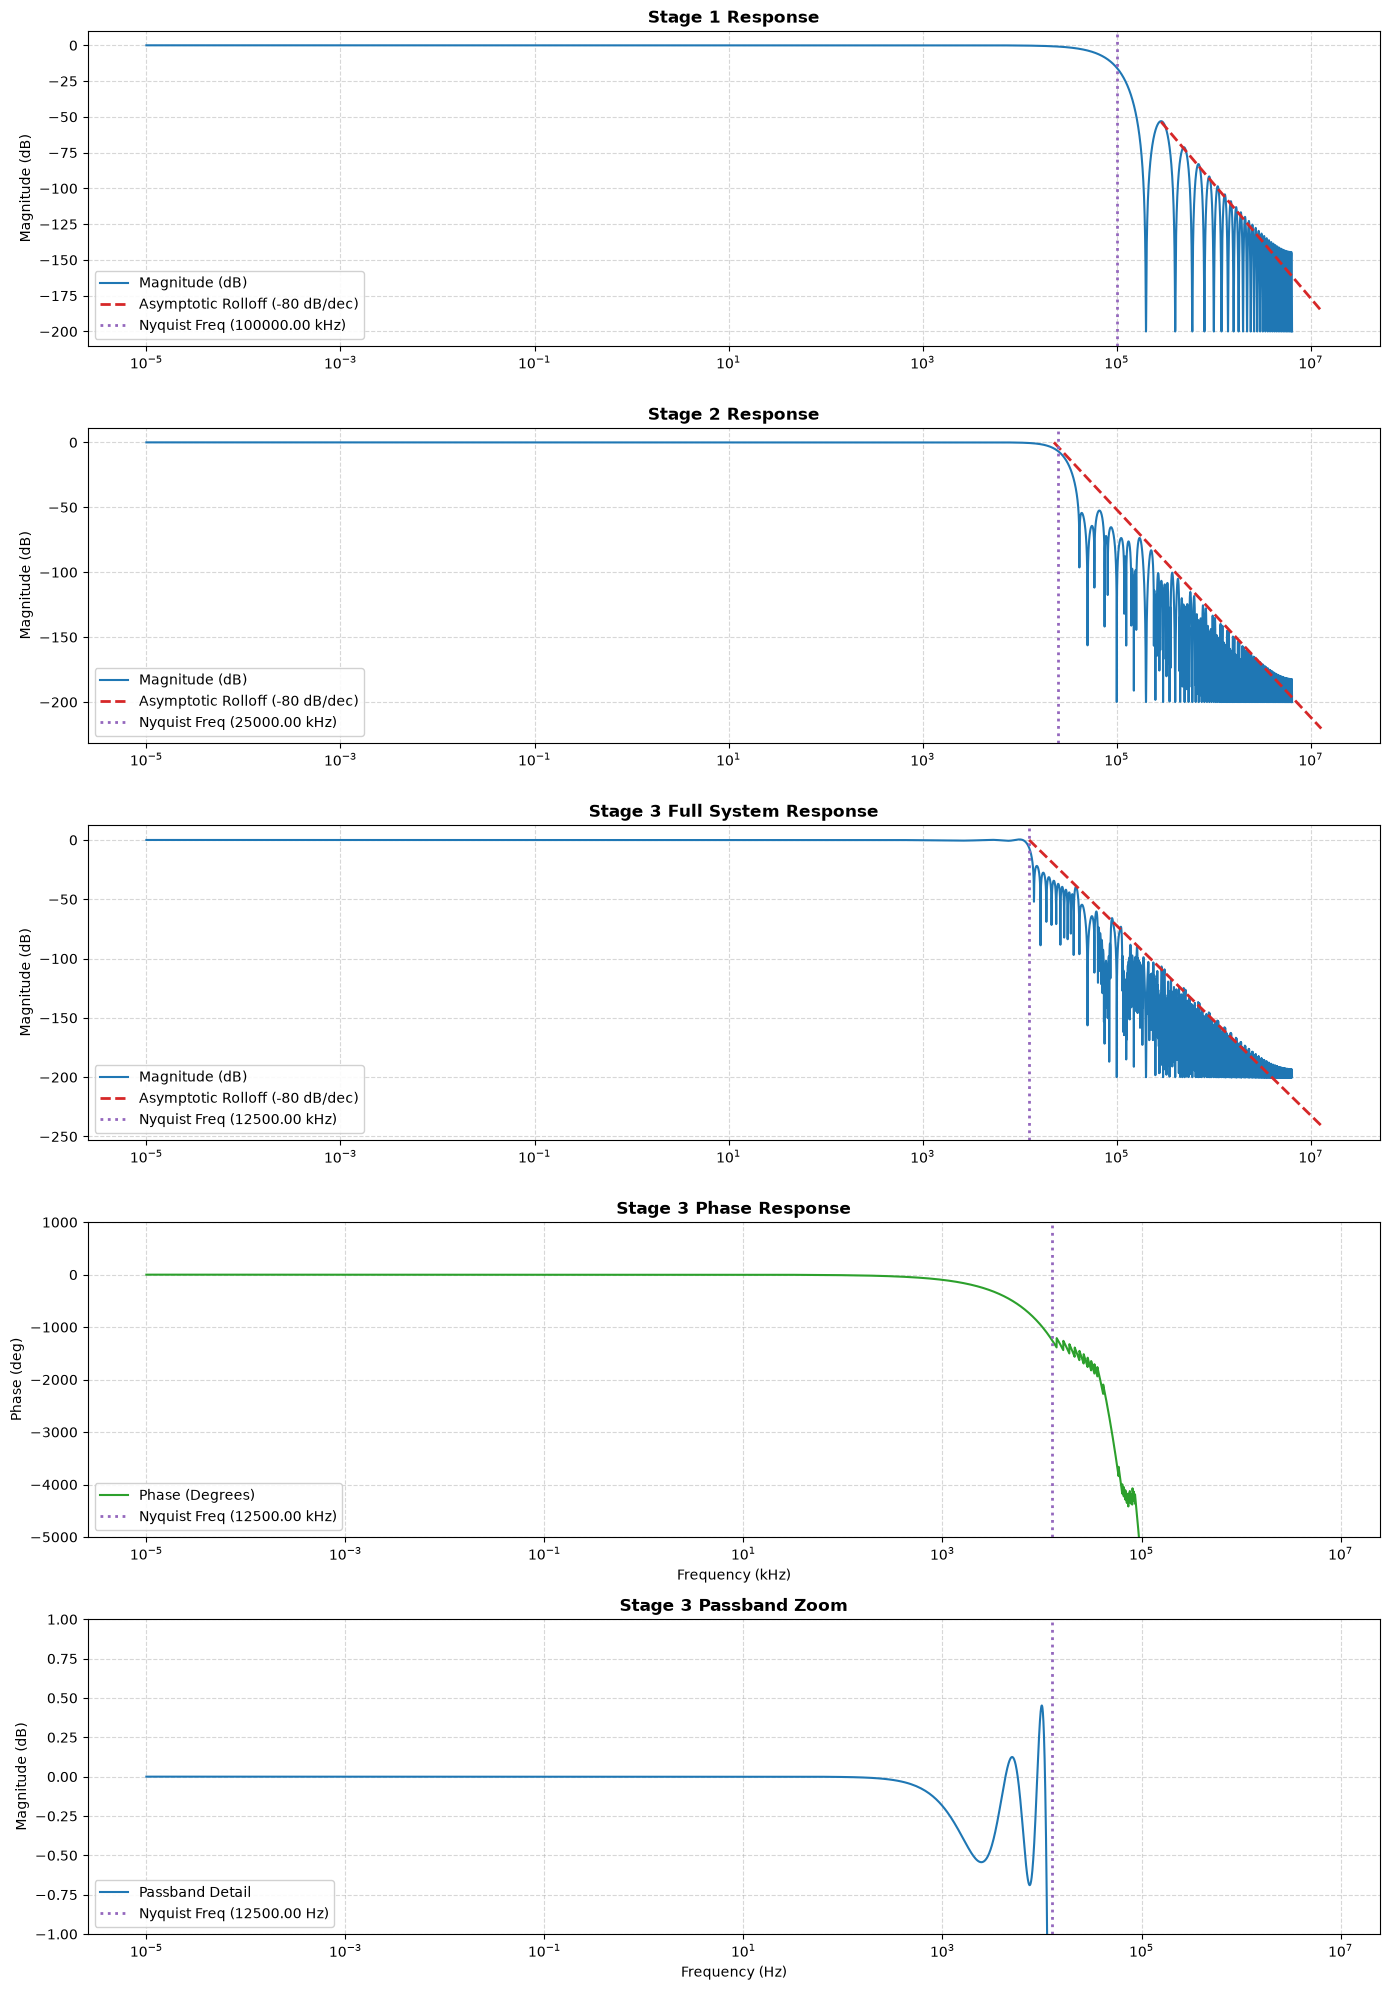

In [164]:
decimator.plot_total_tf()

In [165]:
class DeltaSigmaModulator:
    def __init__(self, order=1, output_format='bipolar'):
        """
        1-Bit Delta-Sigma Modulator (PDM Bitstream Generator).
        
        Parameters:
        order (int): Modulator order (1 or 2).
        output_format (str): 'bipolar' for output values in {-1, +1}
                             'unipolar' for output values in {0, 1}
        """
        if order not in [1, 2, 3]:
            raise ValueError("Order must be either 1 or 2 or 3.")
        if output_format not in ['bipolar', 'unipolar']:
            raise ValueError("output_format must be 'bipolar' or 'unipolar'.")
            
        self.order = order
        self.output_format = output_format

    def modulate(self, input_signal):
        x = np.asarray(input_signal, dtype=np.float64)
        N_samples = len(x)
        bitstream = np.zeros(N_samples, dtype=np.int64)
        
        # State variables for 3 integrators
        v1, v2, v3 = 0.0, 0.0, 0.0

        if self.output_format == 'bipolar':
            # Signal Range: [-0.6, +0.6]
            feedback = 0.0
            for n in range(N_samples):
                err = x[n] - feedback
                
                if self.order == 1:
                    v1 += err
                    quantizer_in = v1
                elif self.order == 2:
                    v1 += 0.5 * err
                    v2 += 0.5 * v1
                    quantizer_in = v2
                elif self.order == 3:
                    # Textbook 3rd-Order CIFF Loop Coefficients
                    # Integrator gains: a1=0.5, a2=0.5, a3=0.5
                    v1 += 0.5 * err
                    v2 += 0.5 * v1
                    v3 += 0.5 * v2
                    # Feedforward weights: c1=1.0, c2=0.6, c3=0.15
                    quantizer_in = 1.0 * v1 + 0.6 * v2 + 0.15 * v3

                # 1-bit Quantizer (Threshold at 0)
                bit = 1 if quantizer_in >= 0 else -1
                bitstream[n] = bit
                feedback = float(bit)

        elif self.output_format == 'unipolar':
            # Signal Range: [0.1, 0.9] (Centered at 0.5)
            feedback = 0.5
            for n in range(N_samples):
                err = x[n] - feedback
                
                if self.order == 1:
                    v1 += err
                    quantizer_in = v1
                elif self.order == 2:
                    v1 += 0.5 * err
                    v2 += 0.5 * v1
                    quantizer_in = v2
                elif self.order == 3:
                    v1 += 0.5 * err
                    v2 += 0.5 * v1
                    v3 += 0.5 * v2
                    quantizer_in = 1.0 * v1 + 0.6 * v2 + 0.15 * v3

                # 1-bit Quantizer
                bit = 1 if quantizer_in >= 0 else 0
                bitstream[n] = bit
                feedback = 1.0 if bit == 1 else 0.0

        return bitstream

In [166]:
t_high = np.arange(0, duration, 1.0 / fs_high)
input_sine = 0.5 + 0.001 * np.sin(2 * np.pi * f_signal * t_high)

In [167]:
dsm = DeltaSigmaModulator(order=3, output_format='unipolar')
bitstream = dsm.modulate(input_sine)
# bitstream = 2*bitstream - 1.0

stage 1 p-p value: (np.float64(0.002049), np.float64(0.501017), np.float64(0.498969))
stage 2 p-p value: (np.float64(0.001998), np.float64(0.500999), np.float64(0.499001))
stage 3 p-p value: (np.float64(0.001954), np.float64(0.500977), np.float64(0.499023))


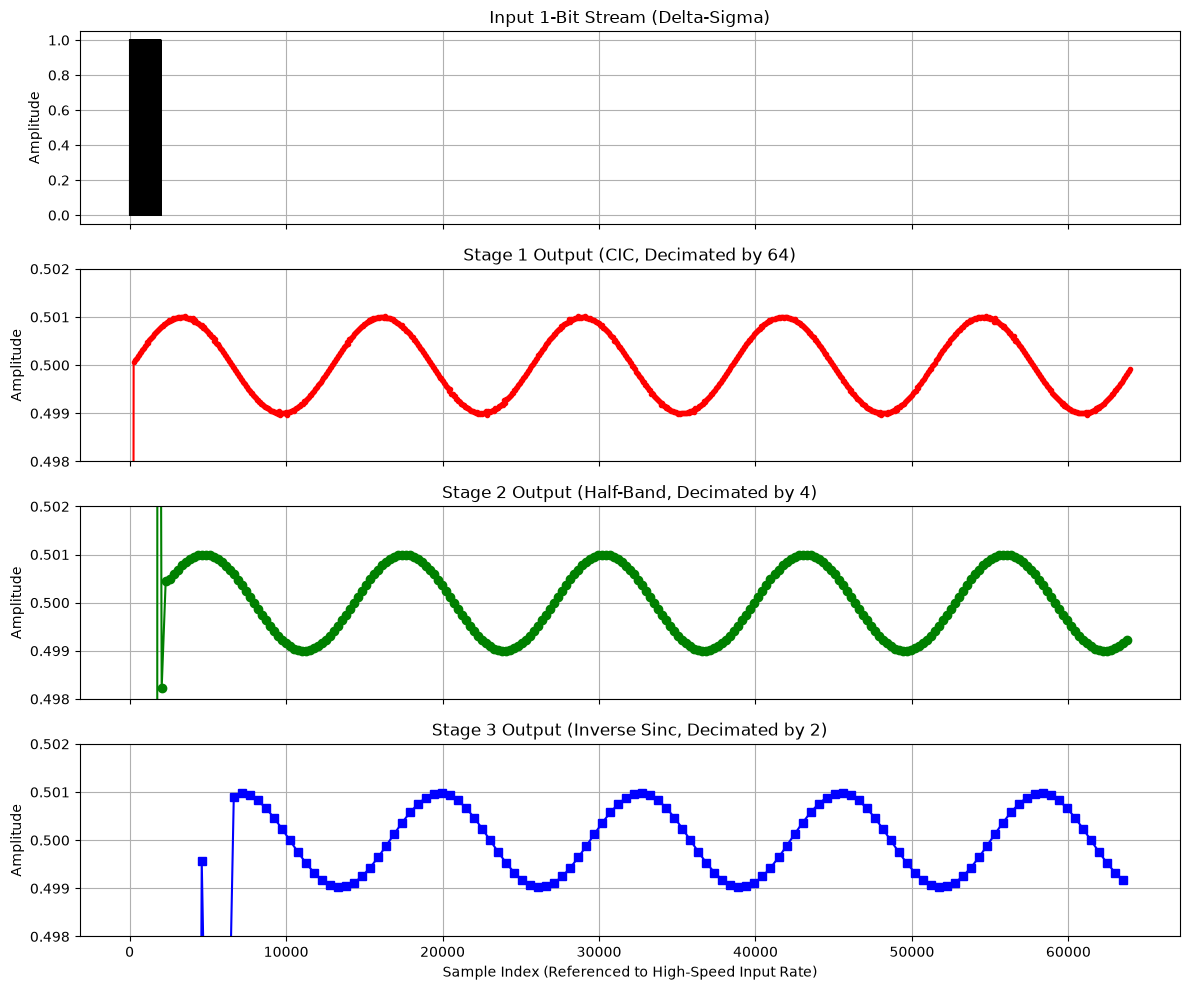

In [168]:
decimator.process_and_plot(bitstream=bitstream)